(245, 42)
             section  pos        team  \
0  standings_overall  1.0  Al Ittihad   
1  standings_overall  2.0    Al Hilal   
2  standings_overall  3.0    Al Nassr   
3  standings_overall  4.0  Al Qadsiah   
4  standings_overall  5.0  Al Ahli SC   

                                            team_url  played   won  drawn  \
0  https://us.soccerway.com/team/al-ittihad/QmsyA...    34.0  26.0    5.0   
1   https://us.soccerway.com/team/al-hilal/hxxcePl9/    34.0  23.0    6.0   
2   https://us.soccerway.com/team/al-nassr/h4I89ZuE/    34.0  21.0    7.0   
3  https://us.soccerway.com/team/al-qadsiah/tvQZt...    34.0  21.0    5.0   
4  https://us.soccerway.com/team/al-ahli-sc/0MHmo...    34.0  21.0    4.0   

   lost  goals_for  goals_against  ...  gp   w   t   l    g  gd pts   o   u  \
0   3.0       79.0           35.0  ... NaN NaN NaN NaN  NaN NaN NaN NaN NaN   
1   5.0       95.0           41.0  ... NaN NaN NaN NaN  NaN NaN NaN NaN NaN   
2   6.0       80.0           38.0  ... NaN 

C:\Users\sheed\AppData\Local\Temp\ipykernel_29556\3245988138.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="result", data=df, palette="Set2")


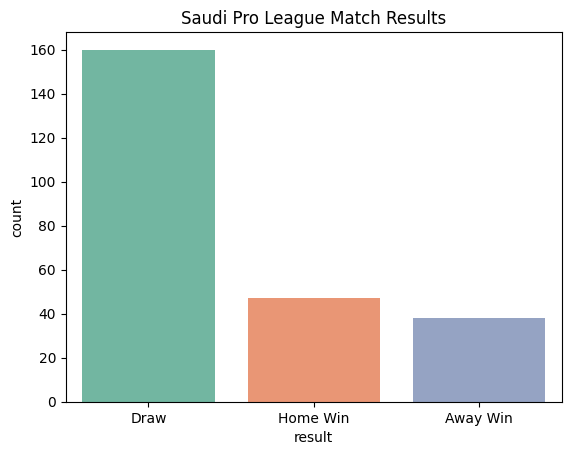

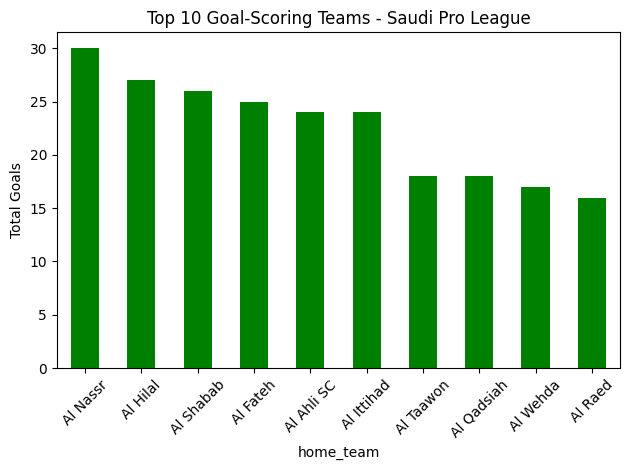

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("C:\\Users\\sheed\\Documents\\github\\saudi-pro-league-analyzer\\data\\spl_matches.csv")

# Basic info
print(df.shape)
print(df.head())
print(df.isnull().sum())

# Add result column
def get_result(row):
    if row["home_goals"] > row["away_goals"]:
        return "Home Win"
    elif row["home_goals"] < row["away_goals"]:
        return "Away Win"
    else:
        return "Draw"

df["result"] = df.apply(get_result, axis=1)

# Plot result distribution
sns.countplot(x="result", data=df, palette="Set2")
plt.title("Saudi Pro League Match Results")
plt.savefig("C:\\Users\\sheed\\Documents\\github\\saudi-pro-league-analyzer\\images\\result_distribution.png")
plt.show()

# Top scoring teams
home_goals = df.groupby("home_team")["home_goals"].sum()
away_goals = df.groupby("away_team")["away_goals"].sum()
total_goals = (home_goals + away_goals).sort_values(ascending=False)

total_goals.head(10).plot(kind="bar", color="green")
plt.title("Top 10 Goal-Scoring Teams - Saudi Pro League")
plt.ylabel("Total Goals")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("C:\\Users\\sheed\\Documents\\github\\saudi-pro-league-analyzer\\images\\top_scorers.png")
plt.show()